 Sleep Health Data Analysis

This notebook explores how lifestyle and physiological indicators relate to sleep quality and sleep disorders.

 1. Import Libraries

In this section, the required Python libraries for data analysis and visualization are imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")


2. Load the Dataset

The dataset is loaded and inspected to understand its structure and variables.

In [4]:
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


3. Initial Data Inspection

This section checks the shape, data types, missing values, and summary statistics of the dataset.

In [5]:
df.shape
df.info()
df.describe(include="all")
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


np.int64(0)

 Initial Observation
The dataset appears relatively clean, with no major structural issues.  
At this stage, the focus is on verifying whether any variables require transformation for better interpretability.

 4. Data Cleaning

This section handles formatting issues and prepares the dataset for analysis.

In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.head()

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


 5. Feature Engineering

To make the analysis more interpretable, the Blood Pressure column is separated into systolic and diastolic values.

In [29]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)
df[['Blood_Pressure', 'Systolic_BP' , 'Diastolic_BP']].head()

,Blood_Pressure,Systolic_BP,Diastolic_BP
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


 Why this matters
Separating blood pressure into systolic and diastolic components makes it easier to analyze cardiovascular patterns in relation to BMI, stress, and sleep-related variables.

 6.Univariate Analysis

This section explores the distribution of individual variables such as age, sleep duration, quality of sleep, and sleep disorders.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

6.1 Age Distribution

This histogram shows how participants are distributed by age.

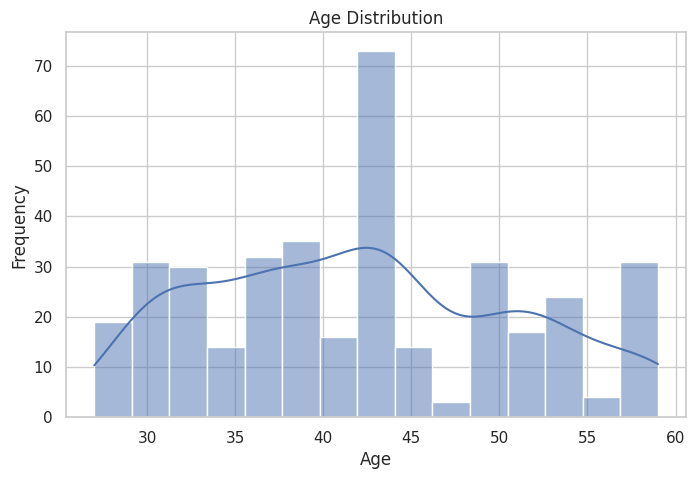

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age of participants ranges from 27 to 59 years, showing a broad representation across different life stages. The distribution is somewhat irregular but features a significant peak around age 42-44, suggesting that a large portion of the dataset consists of mid-career professionals.

6.2 Sleep Duration Distribution

This histogram shows the distribution of sleep duration among participants.

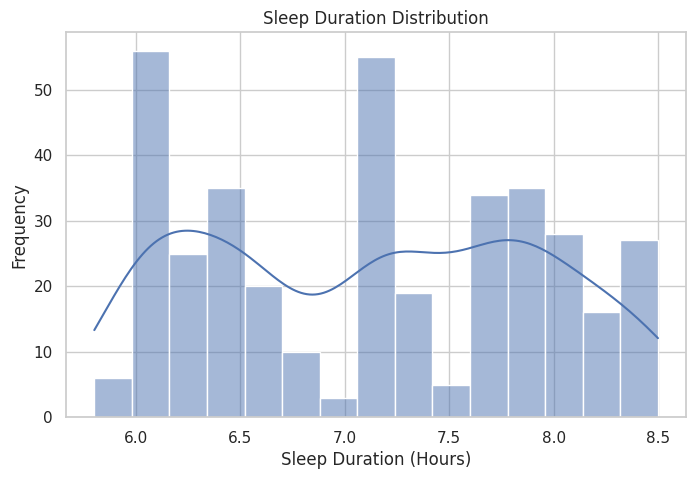

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Sleep_Duration", bins=15, kde=True)
plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Frequency")
plt.show()

Sleep duration follows a multi-modal distribution, with prominent peaks at 6.0, 7.2, and 7.8 hours. This indicates distinct groups within the sample: those getting the minimum recommended sleep and those achieving a more ideal 7-8 hour range. Very few participants sleep less than 6 hours or more than 8.5 hours.

6.3 Quality of Sleep Distribution

This histogram shows how sleep quality scores are distributed.

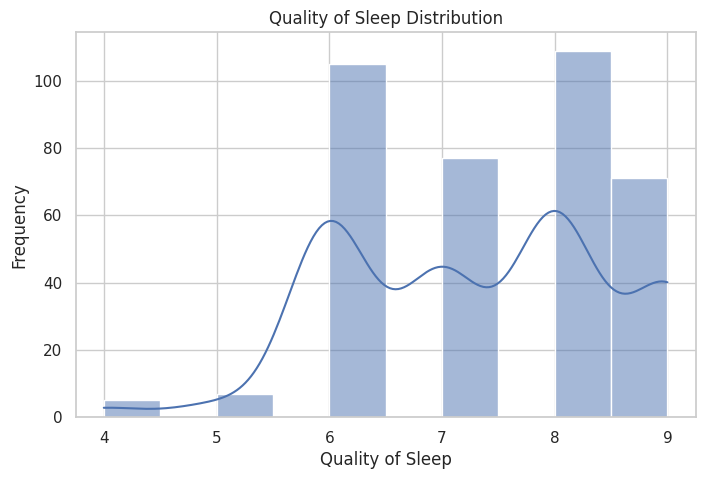

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Quality_of_Sleep", bins=10, kde=True)
plt.title("Quality of Sleep Distribution")
plt.xlabel("Quality of Sleep")
plt.ylabel("Frequency")
plt.show()

The histogram shows a multi-modal distribution of sleep quality. While a significant portion of participants rate their sleep quality at an 8 out of 10, there are noticeable peaks at 6 and 7 as well. Very few participants report a sleep quality below 5, suggesting a generally healthy sample.

6.4 Sleep Disorder Distribution

This countplot shows how many participants belong to each sleep disorder category.

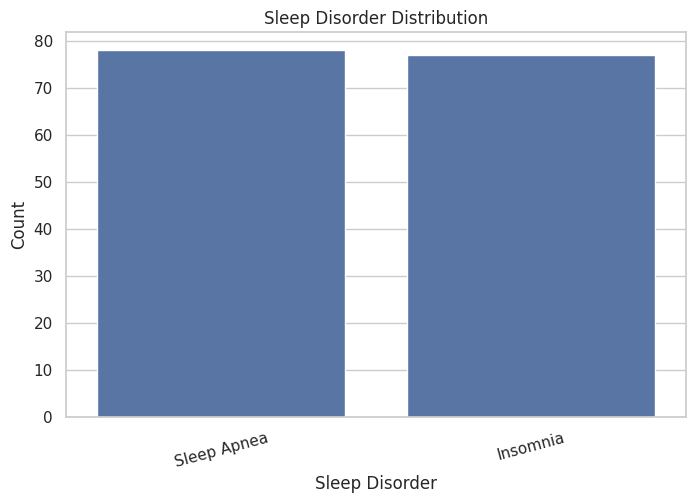

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Sleep_Disorder")
plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

The dataset shows a nearly balanced distribution between two primary conditions: Sleep Apnea and Insomnia. Both categories have a similar count (around 75-80), which allows for a fair comparison of how these different disorders impact other health metrics.

7. Categorical Variable Analysis

This section explores the distribution of important categorical variables in the dataset.

7.1 Gender Distribution

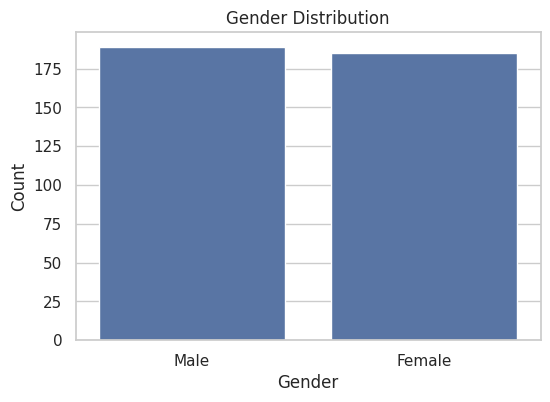

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The participant pool is well-balanced by gender, with a nearly equal number of Male and Female subjects. This balance is crucial for ensuring that the subsequent analysis of sleep patterns and health metrics is not biased toward a specific gender.

7.2 Occupation Distribution

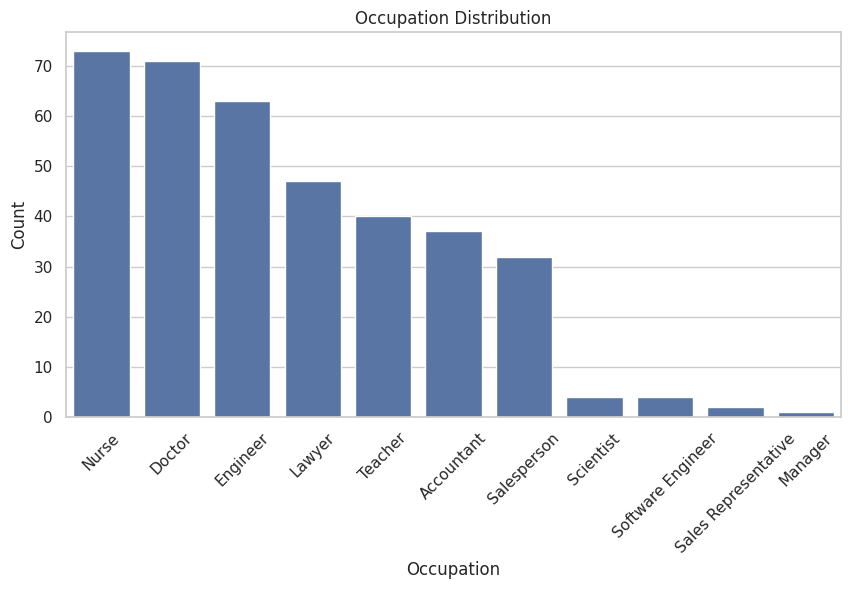

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Occupation", order=df["Occupation"].value_counts().index)
plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The dataset is dominated by Nurses, Doctors, and Engineers, who represent the largest professional groups. In contrast, Managers and Representatives have the lowest representation. This suggests that the findings of this study may be particularly reflective of high-pressure healthcare and technical roles.

7.3 BMI Category Distribution

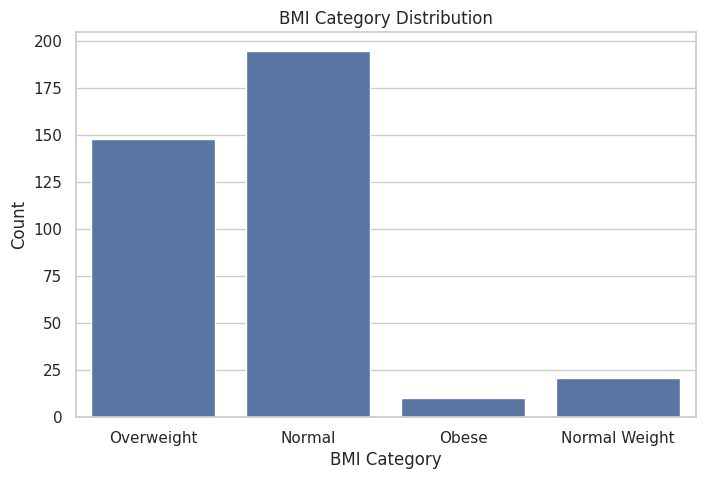

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="BMI_Category")
plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.show()

The majority of participants fall into the Normal weight category, followed closely by Overweight. Interestingly, the categories "Normal" and "Normal Weight" appear to be separated, which might require data cleaning. The "Obese" category represents the smallest portion of the sample.

8. Bivariate Analysis

This section examines relationships between variables to better understand patterns in sleep health.

8.1 Sleep Duration by Gender

This boxplot compares sleep duration across gender groups.

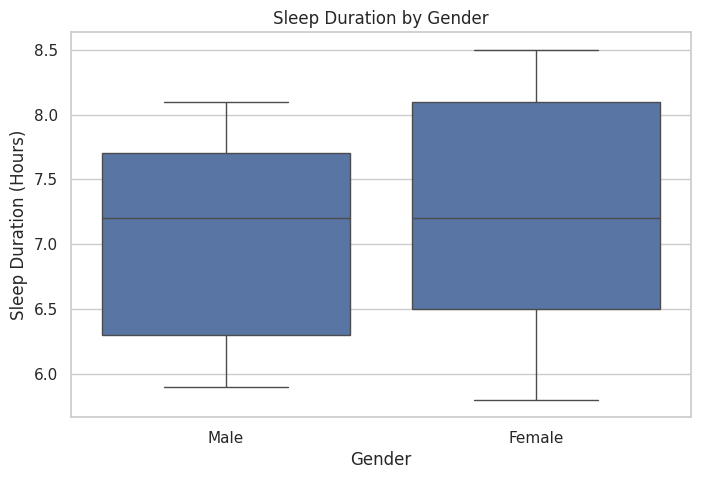

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Gender", y="Sleep_Duration")
plt.title("Sleep Duration by Gender")
plt.xlabel("Gender")
plt.ylabel("Sleep Duration (Hours)")
plt.show()

The boxplot reveals that Females generally have a wider range of sleep duration compared to Males. While both genders share a similar median (around 7.2 hours), the female group includes individuals with both higher and lower sleep extremes, whereas male sleep duration is more tightly clustered.

8.2 Quality of Sleep by Sleep Disorder

This boxplot shows how sleep quality differs across sleep disorder categories.

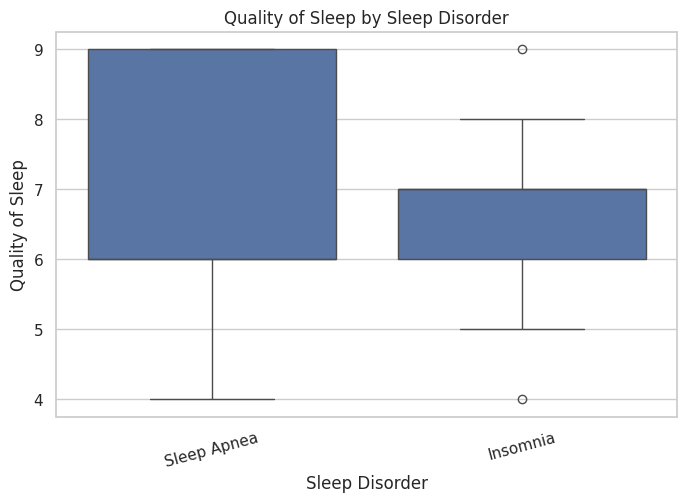

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Sleep_Disorder", y="Quality_of_Sleep")
plt.title("Quality of Sleep by Sleep Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Quality of Sleep")
plt.xticks(rotation=15)
plt.show()

There is a clear distinction in sleep quality between disorders. Sleep Apnea patients exhibit a higher variance, with many achieving a quality score of 9, despite their condition. Conversely, Insomnia patients report consistently lower sleep quality, with the majority of scores concentrated around 6 or 7.

8.3 Stress Level and Quality of Sleep

This scatterplot explores the relationship between stress level and sleep quality.

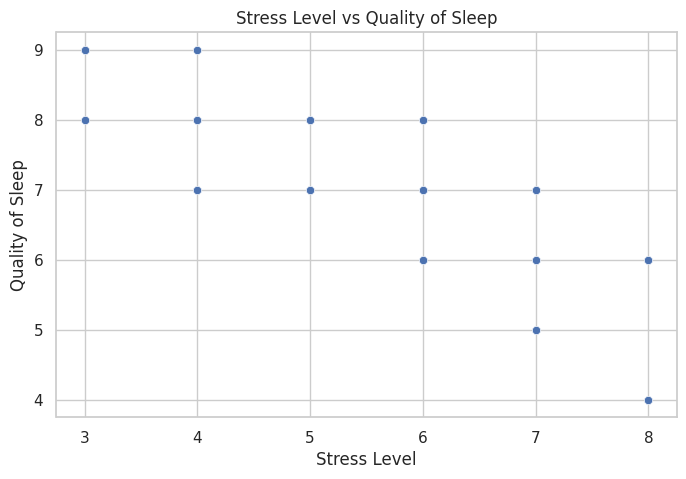

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Stress_Level", y="Quality_of_Sleep")
plt.title("Stress Level vs Quality of Sleep")
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.show()

This scatterplot demonstrates a strong negative correlation between stress and sleep quality. As stress levels increase from 3 toward 8, the quality of sleep scores shows a clear downward trend. High stress (level 8) is almost exclusively associated with the lowest sleep quality scores (4-6).

9. Correlation Analysis

Correlation analysis helps identify linear relationships between numerical variables.

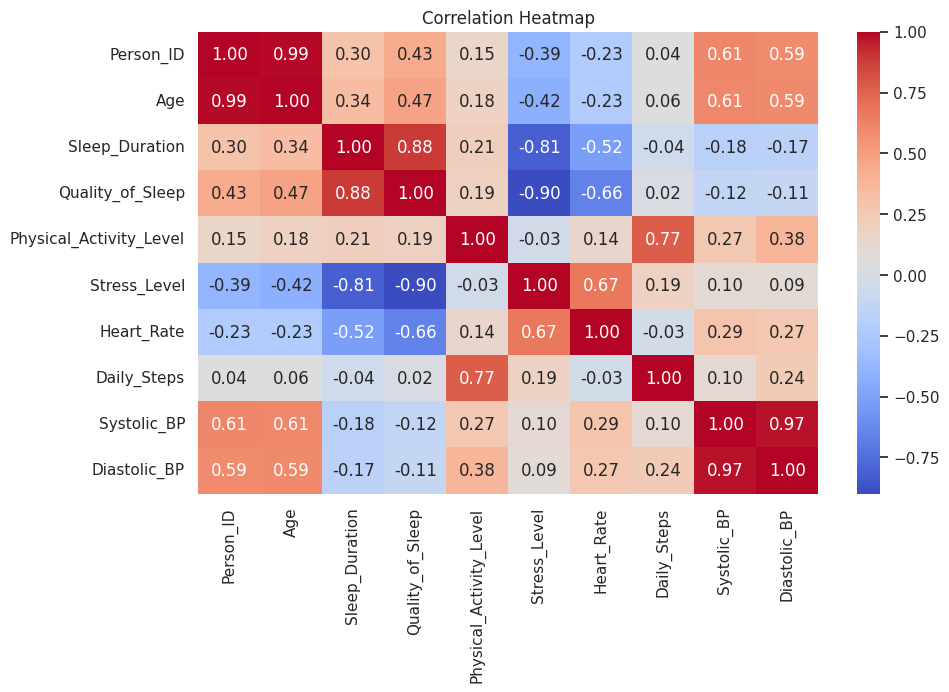

In [27]:
numerical_df = df.select_dtypes(include=["int64", "float64"])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The heatmap confirms several critical relationships:

Quality of Sleep has a very strong positive correlation (0.88) with Sleep Duration.

Stress Level is strongly negatively correlated with both Sleep Duration (-0.81) and Quality of Sleep (-0.90).

Systolic and Diastolic BP are nearly perfectly correlated (0.97), as expected.

/tmp/ipykernel_903/3846299212.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Stress_Level', data=df, palette='viridis', errorbar=None)


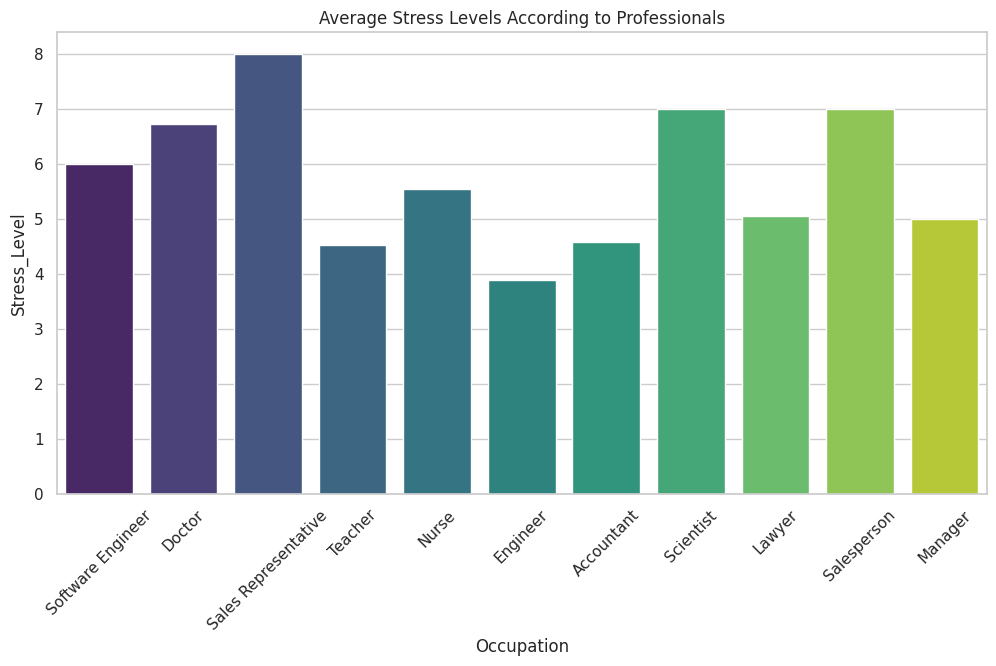

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Occupation', y='Stress_Level', data=df, palette='viridis', errorbar=None)
plt.title('Average Stress Levels According to Professionals')
plt.xticks(rotation=45)
plt.show()

Sales Representatives are the occupational group with the highest stress level (8).
Engineers and Managers reported lower stress levels compared to Doctors.
Whether this high stress level is driving up the Systolic_BP (High Blood Pressure) data that we separated yesterday
will be examined in our next correlation analysis.

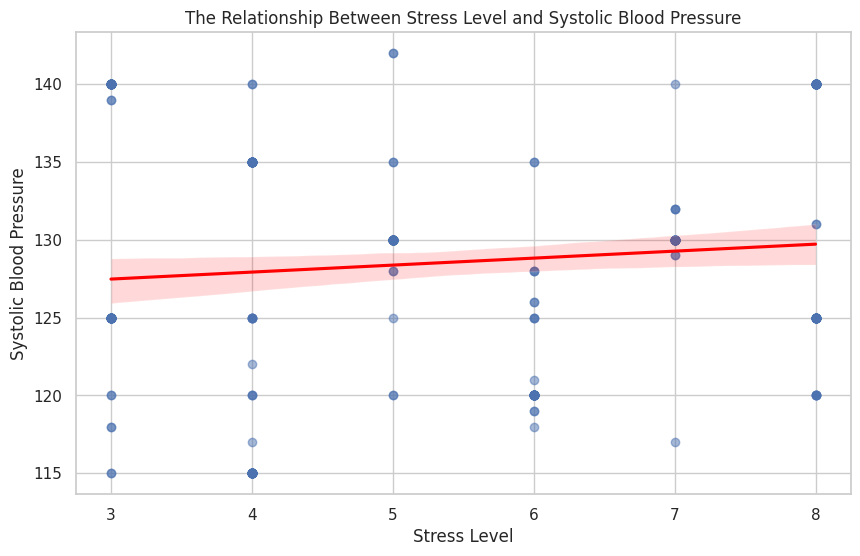

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='Stress_Level', y='Systolic_BP', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('The Relationship Between Stress Level and Systolic Blood Pressure')
plt.xlabel('Stress Level')
plt.ylabel('Systolic Blood Pressure')
plt.show()

In our regression analysis between stress and systolic blood pressure (BP), no significant correlation was found between the two variables.

Even with increased stress levels, blood pressure values ​​exhibit a similar distribution.
Besides stress, other factors such as 'BMI Category' (Weight), 'Age', or 'Physical Activity Level' may have a more dominant effect on blood pressure.

/tmp/ipykernel_903/2841584161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BMI_Category', y='Systolic_BP', data=df, palette='Set2')


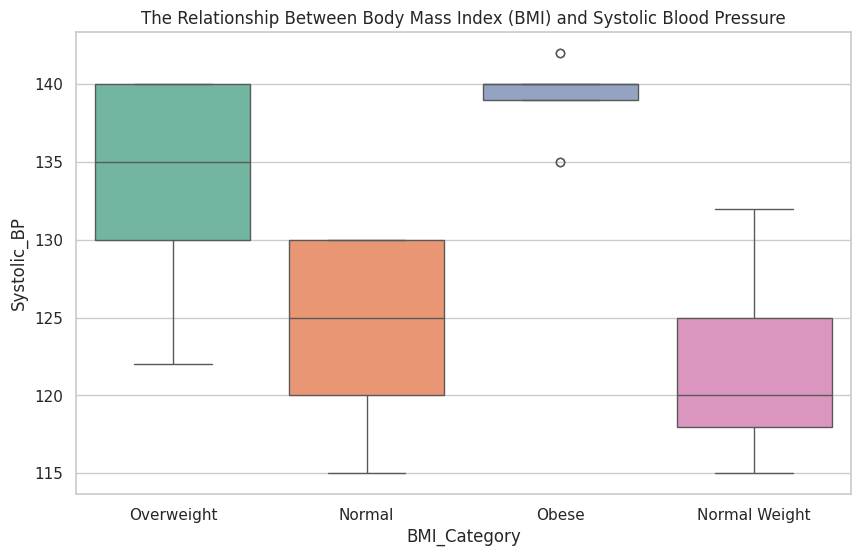

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='BMI_Category', y='Systolic_BP', data=df, palette='Set2')
plt.title('The Relationship Between Body Mass Index (BMI) and Systolic Blood Pressure')
plt.show()

If stress doesn't raise blood pressure, what does?

(The relationship with BMI (Body Mass Index) was examined because the relationship between weight and blood pressure is generally much stronger.)
As seen in the graph above, unlike the stress factor, BMI category was observed to have a direct and strong effect on blood pressure values. Individuals in the overweight category have significantly higher average systolic blood pressure values.
In normal weight individuals, blood pressure values ​​are lower and exhibit a more balanced distribution.
This finding suggests that weight management may be a more significant risk factor than stress for sleep health and blood pressure.

5: Age and Sleep Quality Analysis
In the final analysis of the project, we are examining the effect of the age variable on sleep quality.

This will allow us to see how demographic data combine with health parameters.

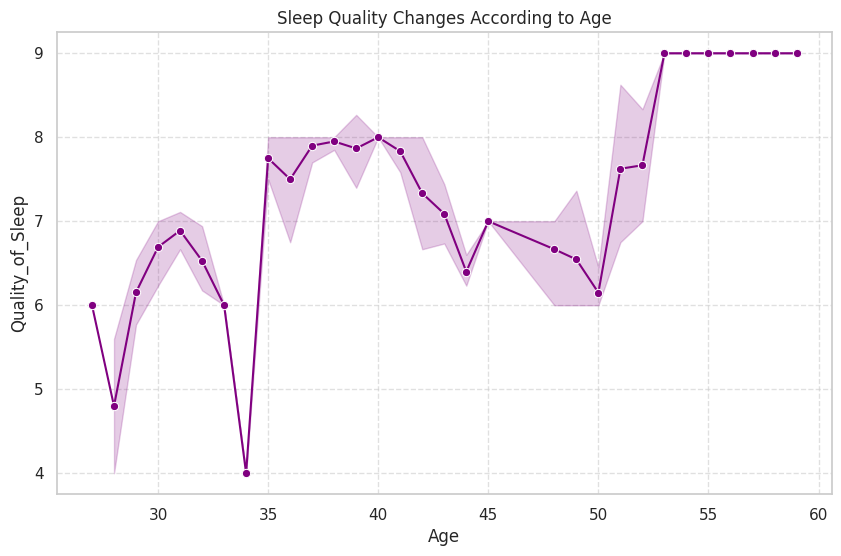

In [36]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age', y='Quality_of_Sleep', data=df, marker='o', color='purple')
plt.title('Sleep Quality Changes According to Age')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

10. Key Insights

Based on the exploratory analysis, several patterns can be observed:

- Age appears to be distributed within a relatively limited adult range.
- Sleep duration is clustered around a moderate number of hours.
- Quality of sleep varies noticeably across participants.
- Some sleep disorder categories appear more frequently than others.
- Higher stress levels may be associated with lower sleep quality.
- Sleep-related variables appear to be meaningfully connected to health and lifestyle indicators.

11. Conclusion

This project explored a sleep health dataset using data cleaning, visualization, and exploratory analysis techniques.

The findings suggest that sleep duration, sleep quality, stress, and lifestyle-related variables may be connected in meaningful ways. Although this is a beginner-level analysis, it provides a solid foundation for future work in data analysis and machine learning.

   Possible Future Improvements

- Add machine learning models
- Perform feature engineering
- Explore more advanced statistical relationships
- Build an interactive dashboard